In [1]:
import aml_pipeline_methods as aml

# Read the csv data

In [4]:
#
# Read in the csv data
#
df_train, (df_test2017, df_test2018, df_test2019) = aml.pull_train_test_datasets()

# Replace NaN values with zero, if any

In [5]:
#
# Replace NaN Values with Zero
#
df_train_o = aml.replace_any_nan_values(df_train)

In [6]:
df_test2017_o = aml.replace_any_nan_values(df_test2017)

In [7]:
df_test2018_o = aml.replace_any_nan_values(df_test2018)

In [8]:
df_test2019_o = aml.replace_any_nan_values(df_test2019)

# Get the feature sets and labels

In [9]:
#
# Get the features-label sets for train, validate and test
#
x_train, y_train = aml.get_features_labels_from_df(df_train_o)

INFO: The shape of the feature set is (2891, 927)
INFO: The shape of the labels is (2891,)


In [10]:
x_test2017, y_test2017 = aml.get_features_labels_from_df(df_test2017_o)

INFO: The shape of the feature set is (193, 927)
INFO: The shape of the labels is (193,)


In [11]:
x_test2018, y_test2018 = aml.get_features_labels_from_df(df_test2018_o)

INFO: The shape of the feature set is (192, 927)
INFO: The shape of the labels is (192,)


In [12]:
x_test2019, y_test2019 = aml.get_features_labels_from_df(df_test2019_o)

INFO: The shape of the feature set is (192, 927)
INFO: The shape of the labels is (192,)


In [29]:
df_train.columns

Index(['Year', 'Week', 'Game Index', 'Home Team', 'Away Team',
       'Away First Quarter Pts Scored season',
       'Home First Quarter Pts Scored season',
       'Away Avg. First Quarter Pts Scored last 1 games',
       'Home Avg. First Quarter Pts Scored last 1 games',
       'Away Avg. First Quarter Pts Scored last 2 games',
       ...
       'Home Punt Return Long Yards season',
       'Away Avg. Punt Return Long Yards last 1 games',
       'Home Avg. Punt Return Long Yards last 1 games',
       'Away Avg. Punt Return Long Yards last 2 games',
       'Home Avg. Punt Return Long Yards last 2 games',
       'Away Avg. Punt Return Long Yards last 3 games',
       'Home Avg. Punt Return Long Yards last 3 games',
       'Away Avg. Punt Return Long Yards last 5 games',
       'Home Avg. Punt Return Long Yards last 5 games', 'Winning Team'],
      dtype='object', length=932)

# Normalize the feature set

In [13]:
#
# Normalize the feature sets
#
x_train_norm, x_test2017_norm = aml.normalize_datasets(x_train, x_test2017)

In [14]:
_, x_test2018_norm = aml.normalize_datasets(x_train, x_test2018)

In [15]:
_, x_test2019_norm = aml.normalize_datasets(x_train, x_test2019)

# Run PCA to select the features

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

### Determine how many components to use

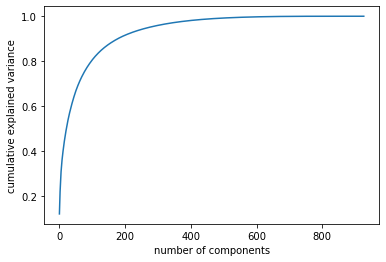

In [17]:
#
# Determine how many components to use
#
pca = PCA().fit(x_train_norm)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

In [18]:
var_pca_vals = pca.explained_variance_ratio_
print(var_pca_vals.shape)
print(var_pca_vals[:5])

(927,)
[0.12251337 0.05349669 0.04440411 0.03324448 0.03071786]


In [19]:
var_cum_sum = np.cumsum(var_pca_vals)
print(var_cum_sum.shape)
print(var_cum_sum[:5])

(927,)
[0.12251337 0.17601006 0.22041418 0.25365866 0.28437652]


In [37]:
%matplotlib qt
plt.plot(range(len(var_cum_sum)), var_cum_sum)
plt.title('Cumulative Explained Variance vs Number of Principal Components', size=24)
plt.xlabel('number of components', size=18)
plt.ylabel('cumulative explained variance (%)', size=18)

# what is the total variance if I choose N components
n_list = list(range(150, 400, 50))
for N in n_list:
    print(f'INFO: for N = {N}, the total variance is {var_cum_sum[N]}')
    plt.plot(N, var_cum_sum[N], marker='*', color='red')
    plt.text(N, var_cum_sum[N], f'({N}, {var_cum_sum[N]:.3})')

INFO: for N = 150, the total variance is 0.8755837704538825
INFO: for N = 200, the total variance is 0.916012859028846
INFO: for N = 250, the total variance is 0.9417802346365568
INFO: for N = 300, the total variance is 0.9595721694518852
INFO: for N = 350, the total variance is 0.9722504031301243


### Use the variance information to choose a set of number to use for components

In [21]:
'''
Choose the lower bound to have at least 80% variance, this is with 100 components
Choose the upper bound to have at least 95% variance, this is with 275 components
'''
N_Components = list(range(100, 400, 50))
for N in N_Components:
    print(f'INFO: for N = {N}, the total variance is {var_cum_sum[N]}')

INFO: for N = 100, the total variance is 0.8063737772074039
INFO: for N = 150, the total variance is 0.8755837704538825
INFO: for N = 200, the total variance is 0.916012859028846
INFO: for N = 250, the total variance is 0.9417802346365568
INFO: for N = 300, the total variance is 0.9595721694518852
INFO: for N = 350, the total variance is 0.9722504031301243


In [22]:
max(var_pca_vals)

0.12251336954846337

In [ ]:
def transform_data_with_pca(x_train:np.ndarray, N:int):
    print(f'INFO: running PCA for {N} components\n')
    pca_ = PCA(n_components=N)
    x_train_pca = pca_.fit_transform(x_train)
    
    return pca_, x_train_pca

# Run PCA to visualize the data

In [23]:
import pandas as pd

In [24]:
pca_ = PCA(n_components=N)
x_train_pca = pca_.fit_transform(x_train_norm)
print(x_train_pca.shape)
print(x_train_pca[:5,:2])

(2891, 350)
[[-15.56938522  -0.32512908]
 [-16.90033388   3.28396576]
 [-15.74469989   6.21007903]
 [-18.54197198  -0.99953181]
 [-16.04159559  -3.04235011]]


In [25]:
df_pca = pd.DataFrame(data=x_train_pca[:,:2], columns=['Principal Component 1', 'Principal Component 2'])
df_pca

,Principal Component 1,Principal Component 2
0,-15.569385,-0.325129
1,-16.900334,3.283966
2,-15.744700,6.210079
3,-18.541972,-0.999532
4,-16.041596,-3.042350
...,...,...
2886,17.484740,3.180271
2887,14.257471,-1.047156
2888,15.657555,8.599513
2889,16.801052,-1.424868


In [26]:
print('Explained variation per principal component: {}'.format(pca_.explained_variance_ratio_[:2]))

Explained variation per principal component: [0.12251337 0.05349669]


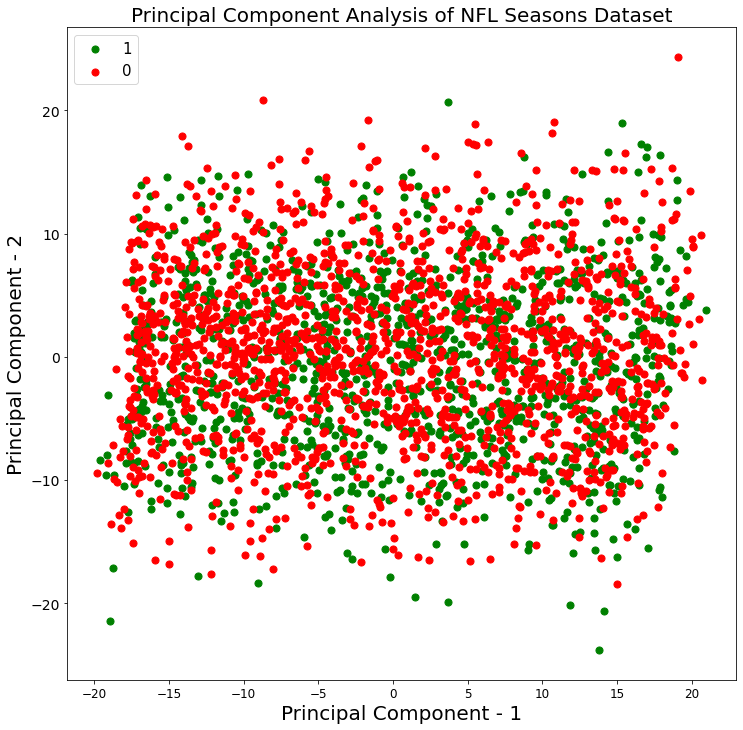

In [27]:
%matplotlib inline
plt.figure(figsize=(12,12))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1',fontsize=20)
plt.ylabel('Principal Component - 2',fontsize=20)
plt.title("Principal Component Analysis of NFL Seasons Dataset",fontsize=20)
targets = [1, 0]
colors = ['g', 'r']
for target, color in zip(targets,colors):
    indicesToKeep = df_train['Winning Team'] == target
    plt.scatter(df_pca.loc[indicesToKeep, 'Principal Component 1']
               , df_pca.loc[indicesToKeep, 'Principal Component 2'], c = color, s = 50)

plt.legend(targets,prop={'size': 15})

(2891, 2)
   Principal Component 1  Principal Component 2
0             -15.569385              -0.325133
1             -16.900334               3.284021
2             -15.744700               6.210308
3             -18.541972              -0.999618
4             -16.041596              -3.042173


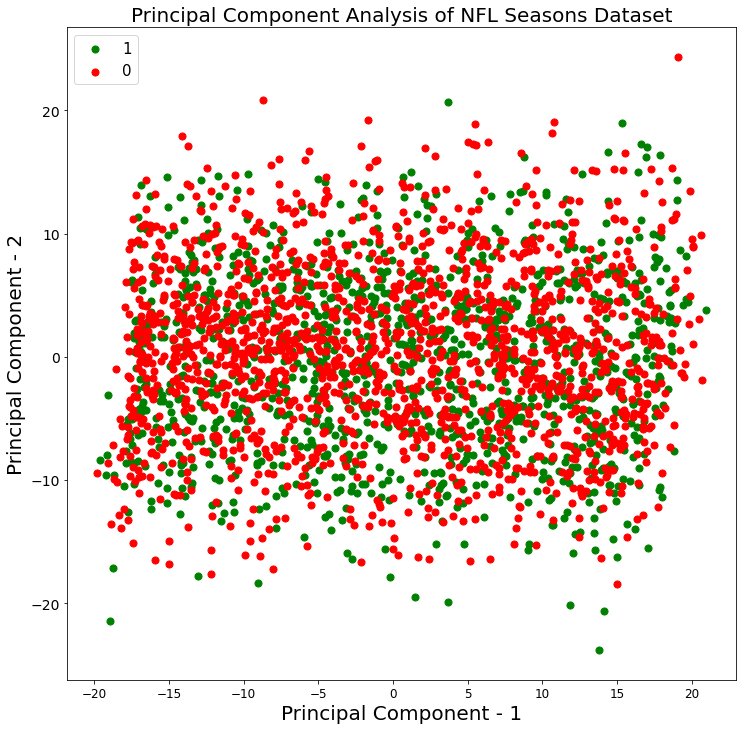

In [28]:
pca_ = PCA(n_components=2)
x_train_pca = pca_.fit_transform(x_train_norm)
print(x_train_pca.shape)

df_pca = pd.DataFrame(data=x_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
print(df_pca.head())

plt.figure(figsize=(12,12))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1',fontsize=20)
plt.ylabel('Principal Component - 2',fontsize=20)
plt.title("Principal Component Analysis of NFL Seasons Dataset",fontsize=20)
targets = [1, 0]
colors = ['g', 'r']
for target, color in zip(targets,colors):
    indicesToKeep = df_train['Winning Team'] == target
    plt.scatter(df_pca.loc[indicesToKeep, 'Principal Component 1']
               , df_pca.loc[indicesToKeep, 'Principal Component 2'], c = color, s = 50)

plt.legend(targets,prop={'size': 15})

In [ ]:
%matplotlib qt
for N in N_Components:
    pca_ = PCA(n_components=N)
    x_train_pca = pca_.fit_transform(x_train_norm)
    
    # create a df out of the data
    df_pca = pd.DataFrame(data=x_train_pca[:,:2], columns=['Principal Component 1', 'Principal Component 2'])
    
    plt.figure(figsize=(12,12))
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=14)
    plt.xlabel('Principal Component - 1',fontsize=20)
    plt.ylabel('Principal Component - 2',fontsize=20)
    plt.title("Principal Component Analysis of NFL Seasons Dataset",fontsize=20)
    targets = [1, 0]
    colors = ['g', 'r']
    for target, color in zip(targets,colors):
        indicesToKeep = df_train['Winning Team'] == target
        plt.scatter(df_pca.loc[indicesToKeep, 'Principal Component 1']
                   , df_pca.loc[indicesToKeep, 'Principal Component 2'], c = color, s = 50)

    plt.legend(targets,prop={'size': 15})

'''
All graphs produced here looked the same
Stick with converting it down to two principal components for data visualization
'''